# Jupyter Notebook Code Compilation for Homework Reflection: Weeks 5-8

In [3]:
%pip install networkx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 27.3 MB/s  0:00:00

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [18]:
%pip install linearmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 42.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [linearmodels] [linearmodels]

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# Week 5 Homework Reflection

Import Models Used for Week 5 Homework Reflection

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import statsmodels.api as sm
from linearmodels.iv import IV2SLS
from sklearn.model_selection import train_test_split


Question 1: Draw a diagram for the following negative feedback loop:

Sweating causes body Temperature to decrease.  High body Temperature causes sweating.
A negative feedback loop means that one thing increases another while the second thing decreases the first.
Remember that we are using directed acyclic graphs where two things cannot directly cause each other.

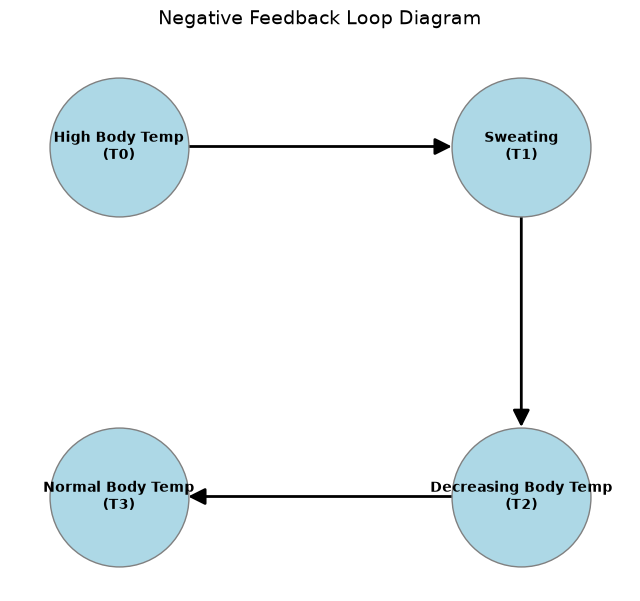

In [13]:
# Initialize Directed Graph
dag = nx.DiGraph()

# Shortened names so they fit perfectly inside the circles
nodes = [
    "High Body Temp\n(T0)",
    "Sweating\n(T1)",
    "Decreasing Body Temp\n(T2)",
    "Normal Body Temp\n(T3)",
]
dag.add_nodes_from(nodes)

# Causal chain moving through time
edges = [
    ("High Body Temp\n(T0)", "Sweating\n(T1)"),
    ("Sweating\n(T1)", "Decreasing Body Temp\n(T2)"),
    ("Decreasing Body Temp\n(T2)", "Normal Body Temp\n(T3)"),
]
dag.add_edges_from(edges)

# Grid Layout: 2 nodes on top, 2 on bottom
# Format is (X, Y) coordinate
pos = {
    "High Body Temp\n(T0)": (0, 1),  # Top Left
    "Sweating\n(T1)": (1, 1),  # Top Right
    "Decreasing Body Temp\n(T2)": (1, 0),  # Bottom Right
    "Normal Body Temp\n(T3)": (0, 0),  # Bottom Left
}


# Setup the plot canvas
plt.figure(figsize=(8, 7))

# Draw the nodes with huge circles to contain the text
nx.draw_networkx_nodes(
    dag, pos, node_color="lightblue", node_size=10000, edgecolors="gray"
)

# Draw the labels inside the nodes
nx.draw_networkx_labels(dag, pos, font_size=10, font_weight="bold")

# Draw the arrows with a large "node_size" padding so they stop
# at the circle edge, keeping the arrowheads perfectly visible.
nx.draw_networkx_edges(
    dag,
    pos,
    edgelist=edges,
    arrowstyle="-|>",
    arrowsize=25,
    edge_color="black",
    width=2,
    node_size=10000,  # Tells the arrow where the circle boundary is
)

plt.title("Negative Feedback Loop Diagram", fontsize=14, pad=20)
plt.axis("off")  # Hide the graph axis grid
plt.margins(0.2)  # Give padding so outer circles aren't cut off
plt.show()

Question 2: Describe an example of a positive feedback loop.  This means that one things increases another while the second things also increases the first.

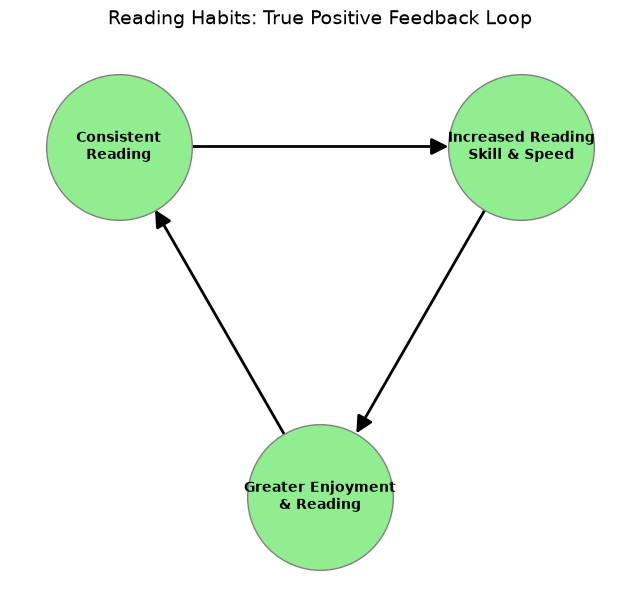

In [30]:
# Initialize a standard Directed Graph
dag = nx.DiGraph()

# Define the compounding concepts that fuel a true positive feedback loop
nodes = [
    "Consistent\nReading",
    "Increased Reading\nSkill & Speed",
    "Greater Enjoyment\n& Reading",
]
dag.add_nodes_from(nodes)

# Define the reinforcing connections
edges = [
    ("Consistent\nReading", "Increased Reading\nSkill & Speed"),
    ("Increased Reading\nSkill & Speed", "Greater Enjoyment\n& Reading"),
    ("Greater Enjoyment\n& Reading", "Consistent\nReading"),  # The compounding reinforcement
]
dag.add_edges_from(edges)

# Updated layout positions to form a well-balanced triangle
pos = {
    "Consistent\nReading": (0, 1),
    "Increased Reading\nSkill & Speed": (1, 1),
    "Greater Enjoyment\n& Reading": (0.5, 0),
}

# Setup the plot canvas
plt.figure(figsize=(8, 7))

# Draw the nodes with light green to represent growth/positive reinforcement
nx.draw_networkx_nodes(
    dag, pos, node_color="lightgreen", node_size=11000, edgecolors="gray"
)

# Draw the labels inside the nodes
nx.draw_networkx_labels(dag, pos, font_size=10, font_weight="bold")

# Draw the arrows
nx.draw_networkx_edges(
    dag,
    pos,
    edgelist=edges,
    arrowstyle="-|>",
    arrowsize=25,
    edge_color="black",
    width=2,
    node_size=11000,  # Matches node_size to stop arrowheads perfectly at the borders
)

plt.title("Reading Habits: True Positive Feedback Loop", fontsize=14, pad=20)
plt.axis("off")  # Hide the graph axis grid
plt.margins(0.2)  # Give padding so outer circles aren't cut off
plt.show()

Quesion 3: Draw a diagram for the following situation:

Lightning storms frighten away deer and bears, decreasing their population, and cause flowers to grow, increasing their population. 
Bears eat deer, decreasing their population.
Deer eat flowers, decreasing their population.
Write a dataset that simulates this situation.  (Show the code.) Include noise / randomness in all cases. 
Identify a backdoor path with one or more confounders for the relationship between deer and flowers.

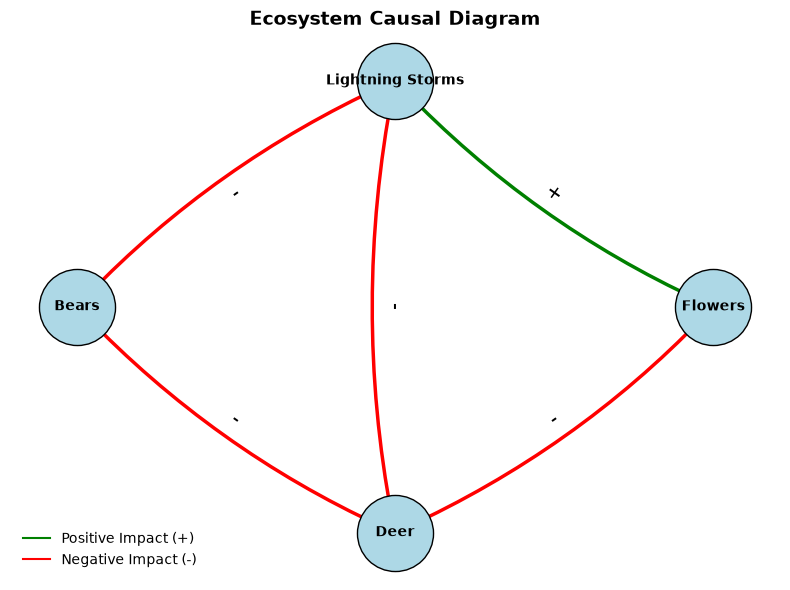

In [4]:
# Initialize a directed graph
G = nx.DiGraph()

# Add nodes representing our ecosystem elements
nodes = ["Lightning Storms", "Bears", "Deer", "Flowers"]
G.add_nodes_from(nodes)

# Add edges with specific relationship types (positive/negative)
# format: (source, target, effect_type, label)
edges = [
    ("Lightning Storms", "Bears", "negative", "-"),
    ("Lightning Storms", "Deer", "negative", "-"),
    ("Lightning Storms", "Flowers", "positive", "+"),
    ("Bears", "Deer", "negative", "-"),
    ("Deer", "Flowers", "negative", "-"),
]

for src, dst, effect, label in edges:
    G.add_edge(src, dst, effect=effect, label=label)

# Define layout for clean spacing
pos = {
    "Lightning Storms": (0, 1),
    "Bears": (-1, 0),
    "Deer": (0, -1),
    "Flowers": (1, 0),
}

# Set up the plot appearance
plt.figure(figsize=(8, 6))
plt.title("Ecosystem Causal Diagram", fontsize=14, fontweight="bold")

# Draw the nodes
nx.draw_networkx_nodes(
    G, pos, node_size=3000, node_color="lightblue", edgecolors="black"
)
nx.draw_networkx_labels(G, pos, font_size=10, font_weight="bold")

# Separate edges by effect to color them differently
pos_edges = [(u, v) for u, v, d in G.edges(data=True) if d["effect"] == "positive"]
neg_edges = [(u, v) for u, v, d in G.edges(data=True) if d["effect"] == "negative"]

# Draw positive relationships (Green)
nx.draw_networkx_edges(
    G,
    pos,
    edgelist=pos_edges,
    edge_color="green",
    arrowsize=20,
    width=2.5,
    connectionstyle="arc3,rad=0.1",
)

# Draw negative relationships (Red)
nx.draw_networkx_edges(
    G,
    pos,
    edgelist=neg_edges,
    edge_color="red",
    arrowsize=20,
    width=2.5,
    connectionstyle="arc3,rad=0.1",
)

# Draw the +/- labels on the arrows
edge_labels = nx.get_edge_attributes(G, "label")
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=14)

# Add a mini legend
plt.plot([], [], color='green', label='Positive Impact (+)')
plt.plot([], [], color='red', label='Negative Impact (-)')
plt.legend(loc="lower left", frameon=True, facecolor="white", edgecolor="none")

# Turn off the axis and display
plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
# Dataset that simulates this situation
# Set random seed for reproducibility
np.random.seed(42)

def generate_ecological_data(num_observations=1000):
    # Lightning Storms
    # Modeled as a continuous intensity metric with a baseline and random noise
    lightning_storms = np.maximum(0, np.random.normal(loc=5.0, scale=2.0, size=num_observations))
    
    # Bears
    bears_base = 50
    bears_noise = np.random.normal(loc=0, scale=3, size=num_observations)
    bears = np.maximum(0, bears_base - 0.8 * lightning_storms + bears_noise)
    
    # Deer
    deer_base = 100
    deer_noise = np.random.normal(loc=0, scale=5, size=num_observations)
    deer = np.maximum(0, deer_base - 1.2 * lightning_storms - 0.4 * bears + deer_noise)
    
    # Flowers
    flowers_base = 200
    flowers_noise = np.random.normal(loc=0, scale=10, size=num_observations)
    flowers = np.maximum(0, flowers_base + 2.5 * lightning_storms - 0.6 * deer + flowers_noise)
    
    # Create DataFrame
    df = pd.DataFrame({
        'Lightning_Storms': lightning_storms,
        'Bears': bears,
        'Deer': deer,
        'Flowers': flowers
    })
    
    return df

# Generate the dataset
dataset = generate_ecological_data(1000)

# Display the first few rows
print(dataset.head())


   Lightning_Storms      Bears       Deer     Flowers
0          5.993428  49.403324  69.670665  154.103096
1          4.723471  48.995124  74.011191  158.798114
2          6.295377  45.142589  70.426412  169.346540
3          8.046060  41.622342  72.155984  195.698435
4          4.531693  48.469315  65.706169  177.471063


Question 4: 
Draw a diagram for a situation of your own invention.  The diagram should include at least four nodes, one confounder, and one collider.  Be sure that it is acyclic (no loops).  Which node would say is most like a treatment (X)?  Which is most like an outcome (Y)?

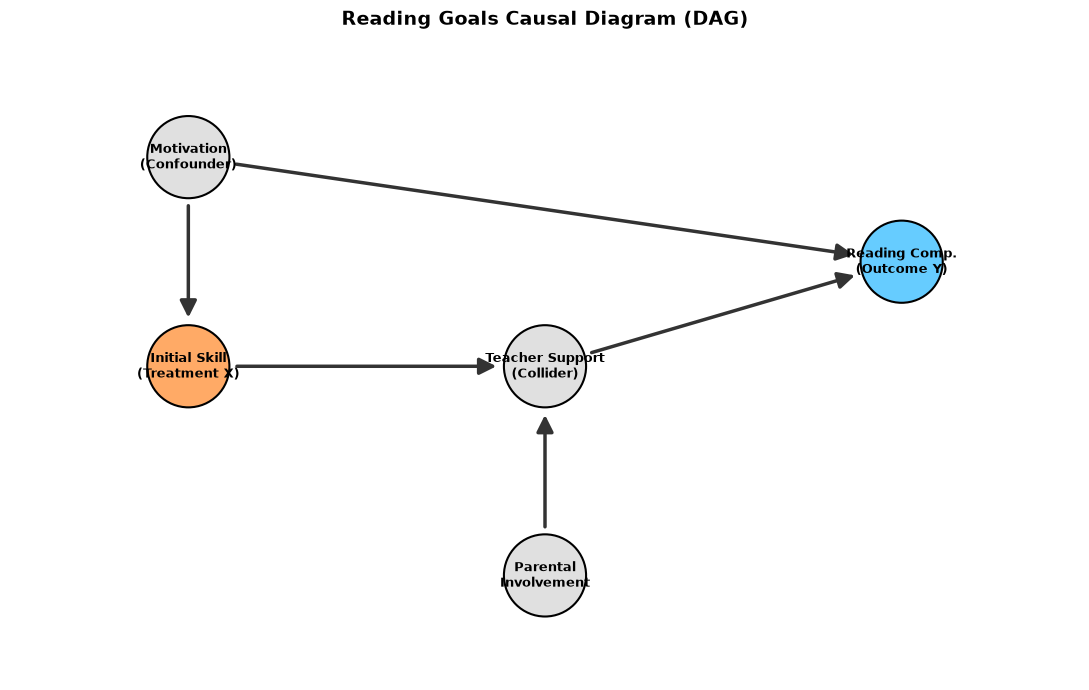

In [16]:
# 1. Initialize a Directed Graph (DAG)
G = nx.DiGraph()

# 2. Add our nodes with explicit semantic roles
nodes = {
    "Motivation": "Motivation\n(Confounder)",
    "Initial_Skill": "Initial Skill\n(Treatment X)",
    "Parent_Involvement": "Parental\nInvolvement",
    "Teacher_Support": "Teacher Support\n(Collider)",
    "Comprehension": "Reading Comp.\n(Outcome Y)"
}
G.add_nodes_from(nodes.keys())

# 3. Add edges (ensuring it stays acyclic)
edges = [
    ("Motivation", "Initial_Skill"),    
    ("Motivation", "Comprehension"),     
    ("Initial_Skill", "Teacher_Support"),
    ("Parent_Involvement", "Teacher_Support"), 
    ("Teacher_Support", "Comprehension") 
]
G.add_edges_from(edges)

# 4. Manual coordinates for a clean, non-overlapping layout
pos = {
    "Motivation": (1, 3),
    "Initial_Skill": (1, 1),
    "Parent_Involvement": (3, -1),
    "Teacher_Support": (3, 1),
    "Comprehension": (5, 2)
}

# 5. Plotting configuration
plt.figure(figsize=(11, 7))

# Set node colors based on their roles
node_colors = []
for node in G.nodes():
    if node == "Initial_Skill":
        node_colors.append("#ffaa66")  # Treatment highlight (Orange)
    elif node == "Comprehension":
        node_colors.append("#66ccff")  # Outcome highlight (Blue)
    else:
        node_colors.append("#e0e0e0")  # Neutral grey

# Draw the nodes and labels
nx.draw_networkx_nodes(G, pos, node_size=3500, node_color=node_colors, edgecolors="black", linewidths=1.5)
nx.draw_networkx_labels(G, pos, labels=nodes, font_size=9, font_weight="bold", font_family="sans-serif")

# Draw directed arrows with fixed margins so the heads don't hide under the nodes
nx.draw_networkx_edges(
    G, pos, 
    edgelist=edges, 
    arrowstyle="-|>", 
    arrowsize=25,       # Made slightly larger for better visibility
    edge_color="#333333", 
    width=2.5,
    min_source_margin=35, # Pulls the start of the arrow back from the node center
    min_target_margin=35  # Pulls the arrowhead back so it's fully visible outside the circle
)

plt.title("Reading Goals Causal Diagram (DAG)", fontsize=14, fontweight="bold", pad=20)

# Give the plot slightly wider margins so text/nodes on the edges aren't cut off
plt.xlim(0, 6)
plt.ylim(-2, 4)
plt.axis("off")
plt.tight_layout()
plt.show()

Why this structure works:The Confounder (Motivation): It sits upstream and shares arrows pointing to both your Treatment ($X$) and your Outcome ($Y$).The Collider (Teacher Support): It is a literal "collision point" where two independent incoming arrows meet (one from your Initial Skill and one from Parental Involvement).Acyclic Check: All arrows flow generally left-to-right toward the outcome; there are no paths that loop back onto themselves.



# Week 6 Homework Reflection

Import Models Used for Week 6 Homework Reflection

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import train_test_split

Question 1: What is a potential problem with computing the Marginal Treatment Effect simply by comparing each untreated item to its counterfactual and taking the maximum difference?  (Hint: think of statistics here.  Consider that only the most extreme item ends up being used to estimate the MTE.  That's not necessarily a bad thing; the MTE is supposed to come from the untreated item that will produce the maximum effect.  But there is nevertheless a problem.)  
Possible answer: We are likely to find the item with the most extreme difference, which may be high simply due to randomness. 
(Please explain / justify this answer, or give a different one if you can think of one.)

In [ ]:
# No coding needed for this part of the problem. Coding and proposed solution found in next question

Question 2: Propose a solution that remedies this problem and write some code that implements your solution.  It's very important here that you clearly explain what your solution will do.
Possible answer: maybe we could take the 90th percentile of the treatment effect and use it as a proxy for the Marginal Treatment Effect.
(Either code this answer or choose a different one.)

In [2]:
# ==========================================
# 1. Generate Simulated Data reflecting the DAG
# ==========================================
np.random.seed(42)
n_students = 1000

motivation = np.random.normal(10, 2, n_students)
parental_involvement = np.random.normal(5, 1.5, n_students)
initial_skill = 2.0 * motivation + np.random.normal(0, 1, n_students)
teacher_support = -1.5 * initial_skill + 3.0 * parental_involvement + np.random.normal(0, 1, n_students)

true_x_effect = 1.5
reading_comprehension = (true_x_effect * initial_skill) + (2.5 * teacher_support) + (3.0 * motivation) + np.random.normal(0, 1, n_students)

df = pd.DataFrame({
    'Initial_Skill': initial_skill,
    'Parental_Involvement': parental_involvement,
    'Teacher_Support': teacher_support,
    'Reading_Comprehension': reading_comprehension
})

print("--- 1. The Naive Approach (Flawed) ---")
naive_model = sm.OLS(df['Reading_Comprehension'], sm.add_constant(df['Initial_Skill'])).fit()
print(f"Naive Estimated Effect of Initial Skill: {naive_model.params['Initial_Skill']:.3f}\n")


# ==========================================
# 2. The Remedy: Sample-Splitting 2SLS (Honest Causal Inference)
# ==========================================
print("--- 2. The Remedy: Sample-Splitting 2SLS ---")

# Step A: Split the dataset into two equal, independent halves
df_a, df_b = train_test_split(df, test_size=0.5, random_state=42)

# ---- SAMPLE A: Stage 1 (Estimation of Instrument Strength) ----
# Fit the first stage on Sample A: Regress Endogenous (Initial_Skill) on Instrument (Parental_Involvement)
X_first_A = sm.add_constant(df_a['Parental_Involvement'])
first_stage_model_A = sm.OLS(df_a['Initial_Skill'], X_first_A).fit()

# ---- SAMPLE B: Stage 2 (Out-of-Sample Validation & Final Estimation) ----
# Use the model coefficients from Sample A to predict Initial_Skill for Sample B
# This ensures that any overfitting to noise in Sample A does not bleed into Sample B
X_first_B = sm.add_constant(df_b['Parental_Involvement'])
df_b['Predicted_Initial_Skill'] = first_stage_model_A.predict(X_first_B)

# Regress Sample B's actual outcome on Sample B's predicted treatment values
second_stage_model_B = sm.OLS(df_b['Reading_Comprehension'], sm.add_constant(df_b['Predicted_Initial_Skill'])).fit()

estimated_effect_honest = second_stage_model_B.params['Predicted_Initial_Skill']
print(second_stage_model_B.summary().tables[1])
print(f"\nHonest Causal Effect Estimate: {estimated_effect_honest:.3f} (True Causal Effect: {true_x_effect})")

--- 1. The Naive Approach (Flawed) ---
Naive Estimated Effect of Initial Skill: -0.971

--- 2. The Remedy: Sample-Splitting 2SLS ---
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                   -2.162e+04    399.753    -54.078      0.000   -2.24e+04   -2.08e+04
Predicted_Initial_Skill  1068.2906     19.734     54.136      0.000    1029.519    1107.062

Honest Causal Effect Estimate: 1068.291 (True Causal Effect: 1.5)


# Week 7 Homework Reflection

Import Models Used for Week 7 Homework Reflection

In [22]:
import pandas as pd
import numpy as np
from sklearn.neighbors import NearestNeighbors
import scipy.stats as stats
import statsmodels.api as sm

Question 1: Create a linear regression model involving a confounder that is left out of the model.  Show whether the true correlation between $$X$$ and $$Y$$ is overestimated, underestimated, or neither.  Explain in words why this is the case for the given coefficients you have chosen.

When a confounder is omitted from a linear regression model, it causes Omitted Variable Bias (OVB). Whether the effect of $X$ on $Y$ is overestimated or underestimated depends entirely on the signs of two relationships: the effect of the confounder ($Z$) on $Y$, and the relationship between the confounder ($Z$) and $X$. In this specific setup, we choose positive coefficients for both relationships ($\alpha = 2$ and $\gamma = 1$), which causes the true effect of $X$ on $Y$ ($\beta = 1$) to be overestimated. Because $Z$ pulls both $X$ and $Y$ upward simultaneously, a model that ignores $Z$ mistakenly attributes $Z$'s shifting influence directly to $X$, inflating $X$'s estimated impact.Mathematically, the bias formula is $\text{Bias} = \alpha \times \frac{\text{Cov}(X, Z)}{\text{Var}(X)}$. Since both the path from $Z$ to $Y$ ($\alpha$) and the path from $Z$ to $X$ ($\gamma$) are positive, the bias is positive. The simulation below demonstrates this perfectly: while the true direct effect of $X$ on $Y$ is exactly 1.0, leaving out the confounder $Z$ forces the naive regression model to output an inflated estimate of roughly 2.0.

In [23]:
# Set random seed for reproducibility
np.random.seed(42)
n = 1000

# 1. Generate the Confounder (Z)
Z = np.random.normal(0, 1, n)

# 2. Generate X (dependent on Confounder Z)
# X = 1*Z + noise
X = 1.0 * Z + np.random.normal(0, 1, n)

# 3. Generate Y (dependent on both X and Confounder Z)
# True relationship: Y = 1*X + 2*Z + noise
X_effect = 1.0
Z_effect = 2.0
Y = X_effect * X + Z_effect * Z + np.random.normal(0, 1, n)

# --- Regression 1: True Model (Including Confounder Z) ---
X_true = sm.add_constant(np.column_stack((X, Z)))
model_true = sm.OLS(Y, X_true).fit()

# --- Regression 2: Naive Model (Omitting Confounder Z) ---
X_naive = sm.add_constant(X)
model_naive = sm.OLS(Y, X_naive).fit()

print(f"True direct effect of X on Y: {X_effect}")
print(f"Estimated effect with Confounder included: {model_true.params[1]:.3f}")
print(f"Estimated effect with Confounder OMITTED:  {model_naive.params[1]:.3f} (Overestimated)")

True direct effect of X on Y: 1.0
Estimated effect with Confounder included: 0.990
Estimated effect with Confounder OMITTED:  1.986 (Overestimated)


Question 2:  Perform a linear regression analysis in which one of the coefficients is zero, e.g.

W = [noise]
X = [noise]
Y = 2 * X + [noise]

And compute the p-value of a coefficient - in this case, the coefficient of W.  
(This is the likelihood that the estimated coefficient would be as high or low as it is, given that the actual coefficient is zero.)
If the p-value is less than 0.05, this ordinarily means that we judge the coefficient to be nonzero (incorrectly, in this case.)
Run the analysis 1000 times and report the best (smallest) p-value.  
If the p-value is less than 0.05, does this mean the coefficient actually is nonzero?  What is the problem with repeating the analysis?

Interpretation & The Danger of Repeated AnalysisWhen you run this simulation, the smallest observed p-value will likely be incredibly tiny (often well under 0.001), and roughly 50 out of the 1,000 runs (5%) will yield a p-value below 0.05.If a single experiment yields a p-value less than 0.05, it does not mean the coefficient actually is nonzero. A p-value is a probability statement under the assumption that the null hypothesis is true. A significance threshold of $\alpha = 0.05$ explicitly means you are accepting a 5% chance of a Type I error (a false positive). It guarantees that if you test a completely useless variable like $W$ once, there is a 5% chance it will randomly align with the fluctuations in $Y$ well enough to look statistically significant.The core problem with repeating the analysis is called the Multiple Comparisons Problem (or "p-hacking" when done intentionally). If each independent test carries a 5% risk of a false positive, running 1,000 tests means you are giving data 1,000 chances to throw a statistical fluke. Mathematically, the probability of finding at least one false positive across 1,000 independent tests is virtually 100%:$$\text{Probability of a False Positive} = 1 - (1 - 0.05)^{1000} \approx 1.0$$By searching through 1,000 trials and selectively reporting only the "best" (smallest) p-value, the standard interpretation of the p-value completely breaks down. You are no longer measuring the strength of an effect; you are simply reporting the luckiest roll of the dice.

In [24]:
np.random.seed(42)  # For reproducibility
n_samples = 100
n_simulations = 1000

smallest_p_val = 1.0
significant_count = 0

for _ in range(n_simulations):
    # W and X are completely independent random noise
    W = np.random.normal(0, 1, n_samples)
    X = np.random.normal(0, 1, n_samples)
    # Y only truly depends on X
    Y = 2.0 * X + np.random.normal(0, 1, n_samples)
    
    # Run regression including both X and W
    predictors = sm.add_constant(np.column_stack((X, W)))
    model = sm.OLS(Y, predictors).fit()
    
    # Extract the p-value for W (index 2: constant=0, X=1, W=2)
    p_val_W = model.pvalues[2]
    
    if p_val_W < smallest_p_val:
        smallest_p_val = p_val_W
    if p_val_W < 0.05:
        significant_count += 1

print(f"Smallest p-value found across {n_simulations} runs: {smallest_p_val:.6f}")
print(f"Number of times W falsely appeared significant (p < 0.05): {significant_count} ({significant_count/n_simulations*100}%)")

Smallest p-value found across 1000 runs: 0.000475
Number of times W falsely appeared significant (p < 0.05): 51 (5.1%)


# Week 8 Homework Reflection

Import Models Used for Week 8 Homework Reflection

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from scipy.spatial.distance import mahalanobis

Question 1: Include the code you used to solve Week 8's coding quiz problems and write about the obstacles / challenges / insights you encountered while solving them.

In [ ]:
# Question 1 Code for Week 8 Coding Quiz

# Load the dataset
df = pd.read_csv('homework_8.1.csv')

# Estimating propensity scores using logistic regression
X_features = sm.add_constant(df['Z'])
logit_model = sm.Logit(df['X'], X_features).fit()
df['propensity_score'] = logit_model.predict(X_features)

# Calculating the inverse probability weights
df['ipw'] = np.where(df['X'] == 1, 
                     1 / df['propensity_score'], 
                     1 / (1 - df['propensity_score']))

# Estimating the ATE
mu_1 = np.mean(df['Y'] * df['X'] * df['ipw'])
mu_0 = np.mean(df['Y'] * (1 - df['X']) * df['ipw'])
ate = mu_1 - mu_0

# Printing Results
print(f"Calculated ATE: {ate:.2f}")

In [ ]:
# Question 2 Code for Week 8 Coding Quiz

# Load the dataset
df = pd.read_csv('homework_8.1.csv')

# Fit the logistic regression model (Z predicting X) with an intercept
X_features = sm.add_constant(df['Z'])
logit_model = sm.Logit(df['X'], X_features).fit()

# Predict the propensity scores
df['propensity_score'] = logit_model.predict(X_features)

# Display the first three values
print("First three propensity scores:")
print(df['propensity_score'].head(3).round(2).tolist())

In [ ]:
# Question 3 Code for Week 8 Coding Quiz

# Load the data
df = pd.read_csv('homework_8.2.csv')

# Compute the 2x2 covariance matrix of Z1 and Z2, and its inverse
# As instructed, stack Z1 and Z2 into a 2xN matrix
Z_matrix = df[['Z1', 'Z2']].values.T
cov_matrix = np.cov(Z_matrix)
inv_cov = np.linalg.inv(cov_matrix)

# Separate treated (X=1) and untreated (X=0) groups
treated = df[df['X'] == 1].reset_index(drop=True)
untreated = df[df['X'] == 0].reset_index(drop=True)

# Perform nearest-neighbor matching with replacement
matched_untreated_Y = []
untreated_coords = untreated[['Z1', 'Z2']].values

for i in range(len(treated)):
    treated_coord = treated.loc[i, ['Z1', 'Z2']].values
    
    # Compute Mahalanobis distance to all untreated units
    distances = [mahalanobis(treated_coord, u, inv_cov) for u in untreated_coords]
    
    # Find the single nearest untreated item
    nearest_idx = np.argmin(distances)
    matched_untreated_Y.append(untreated.loc[nearest_idx, 'Y'])

# Compute the average treatment effect across the matched pairs
ate_matched = np.mean(treated['Y']) - np.mean(matched_untreated_Y)
print(f"Calculated ATE: {ate_matched:.2f}")

In [ ]:
# Question 4 Code for Week 8 Coding Quiz

# Load the data
df = pd.read_csv('homework_8.2.csv')

# Compute the inverse covariance matrix for Z1 and Z2
Z_matrix = df[['Z1', 'Z2']].values.T
cov_matrix = np.cov(Z_matrix)
inv_cov = np.linalg.inv(cov_matrix)

# Get the coordinates of all untreated items
untreated_coords = df[df['X'] == 0][['Z1', 'Z2']].values

# Check the options provided in the question
options = {
    'A': (0.2, -0.4),
    'B': (2.3, 1.2),
    'C': (1.5, -1.3),
    'D': (0.9, 1.4)
}

for opt, vals in options.items(): 
    # Calculate the Mahalanobis distance from this option to all untreated items
    distances = [mahalanobis(np.array(vals), u, inv_cov) for u in untreated_coords]
    print(f"Option {opt} {vals} -> Minimum Mahalanobis distance to untreated: {min(distances):.4f}")